<a href="https://colab.research.google.com/github/AbelAtares/Delaney_Solubility_with_Descriptors/blob/main/Delaney-Solubility-with-Descriptors(LinnerRegression%26RandomForest_Models).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Delaney Solubility with Descriptors**

Welcome to the "Delaney Solubility with Descriptors" project! This repository features a machine learning model designed to predict the solubility of compounds using various molecular descriptors. 📊🔬

We're going to use two models: the first is a linear regression model and the second is a random forest model.

## **Linear Regression Model**

### **Loading and preparing data**

First, we load the dataset from the repository and examine the structure of the dataframe. Next, we create the X variable to store the features and the Y variable for the target.

In [3]:
import pandas as pd

In [4]:
df=pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv')
df

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


In [5]:
X=df.drop('logS',axis=1)
X

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,2.59540,167.850,0.0,0.000000
1,2.37650,133.405,0.0,0.000000
2,2.59380,167.850,1.0,0.000000
3,2.02890,133.405,1.0,0.000000
4,2.91890,187.375,1.0,0.000000
...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000
1140,3.42130,286.114,2.0,0.333333
1141,3.60960,308.333,4.0,0.695652
1142,2.56214,354.815,3.0,0.521739


In [6]:
Y=df['logS']
Y

,logS
0,-2.180
1,-2.000
2,-1.740
3,-1.480
4,-3.040
...,...
1139,1.144
1140,-4.925
1141,-3.893
1142,-3.790


We split the data into training and test sets, with 80% of the data used for training and 20% for testing.

In [7]:
from sklearn.model_selection import train_test_split


In [8]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=11)

In [9]:
X_train, X_test

(      MolLogP    MolWt  NumRotatableBonds  AromaticProportion
 1021 -7.57140  504.438                8.0            0.000000
 123   7.92740  395.327                1.0            0.631579
 961   1.35060  151.165                1.0            0.545455
 26    1.05940  118.176                5.0            0.000000
 1107  2.83260  112.216                0.0            0.000000
 ...       ...      ...                ...                 ...
 850   2.43350  198.653                1.0            0.461538
 583   4.60460  266.340                3.0            0.600000
 332   5.76304  256.348                0.0            0.900000
 1115  0.83340  253.269                1.0            0.842105
 1104  2.82402  150.221                1.0            0.545455
 
 [915 rows x 4 columns],
       MolLogP    MolWt  NumRotatableBonds  AromaticProportion
 60     3.3517  179.101                5.0            0.000000
 326    1.1051  224.260                3.0            0.000000
 671    6.3720  376.496     

In [10]:
Y_train

,logS
1021,-0.410
123,-8.940
961,-1.030
26,-0.770
1107,-4.470
...,...
850,-2.890
583,-4.950
332,-7.010
1115,-2.404


In [11]:
Y_test


,logS
60,-4.430
326,-2.253
671,-8.600
584,-7.278
651,-0.040
...,...
277,-4.470
1124,-5.752
346,-6.200
665,-2.770


As you can see, the number of rows in the training and test sets aligns with the total number of rows in the original dataset.

### **Model**

Now, let's apply linear regression model to fit the data as follows.

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr=LinearRegression()
lr.fit(X_train,Y_train)

LinearRegression()

In [14]:
lr.score(X_train,Y_train)

0.7767801152371718

The linear regression model achieved an R² of 0.77, indicating that it explains 77% of the variability in the target variable.

Now, let's compute predictions for X_test so we can compare them with the actual values in Y_test.

In [15]:
Y_pred=lr.predict(X_test)
Y_pred

array([-3.33263647, -2.00635893, -7.10969195, -8.64778076, -0.70883742,
       -1.12344413,  0.74115997, -2.81288566, -2.58623682,  0.86896718,
       -3.13730931, -1.73407391, -4.70185331, -1.86457861, -0.25727039,
       -4.01723516, -4.26004375, -3.89931203, -1.18559267, -3.59637834,
       -0.14478055, -1.27781376, -3.07148169, -1.85030284, -4.28692025,
       -4.1608926 , -4.30065851, -1.95862477, -2.11660729, -1.60941565,
       -4.97107491, -7.22713935, -5.76306848, -3.60602879, -0.43011283,
       -0.47937367, -2.88135755,  0.05129009, -0.75739924, -3.14219638,
       -3.65117946, -2.20257941, -1.98162838, -2.68272356, -3.58947917,
       -2.23130837, -4.56907178, -2.69957414, -1.58980358, -3.99253023,
       -2.21301788, -1.4793025 , -3.87412985, -1.98082363, -2.96245728,
       -2.2867618 , -1.81560537, -2.06824566, -4.14061071, -2.84685403,
       -0.49769374, -6.61087968, -4.18542535, -3.91119581, -0.98937955,
       -1.80118052, -1.24046524, -3.50610734, -4.98919689, -4.04

In [16]:
Y_test

,logS
60,-4.430
326,-2.253
671,-8.600
584,-7.278
651,-0.040
...,...
277,-4.470
1124,-5.752
346,-6.200
665,-2.770


### **Model evaluation**

In this section, we will evaluate the model using MSE and R² on the test data.

In [28]:
from sklearn.metrics import mean_squared_error,r2_score
from math import sqrt

In [30]:
lr_mse_train=mean_squared_error(Y_test,Y_pred)
lr_r2_score_train=r2_score(Y_test,Y_pred)
print("MSE:",lr_mse_train)
print("RMSE:",sqrt(lr_mse_train))
print("R2:",lr_r2_score_train)

MSE: 1.0777462873363313
RMSE: 1.0381456002586205
R2: 0.7377238790185194


As you can see, the R² score is almost the same as the previous value obtained with the training data. On the other hand, the RMSE of approximately 1 indicates that the predictions tend to deviate by about one unit from the actual values.

### **Data visualization**

Here, we represent all the data in scatter plots to gain a deeper intuition about what is going on.

In [19]:
import matplotlib.pyplot as plt

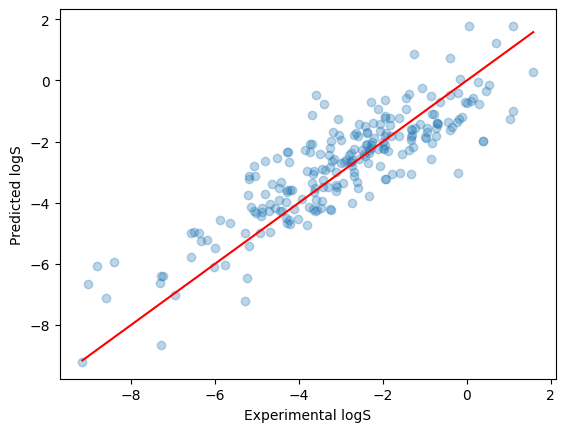

In [31]:
plt.scatter(Y_test,Y_pred,alpha=0.3)
plt.xlabel('Experimental logS')
plt.ylabel('Predicted logS')
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red')
plt.show()

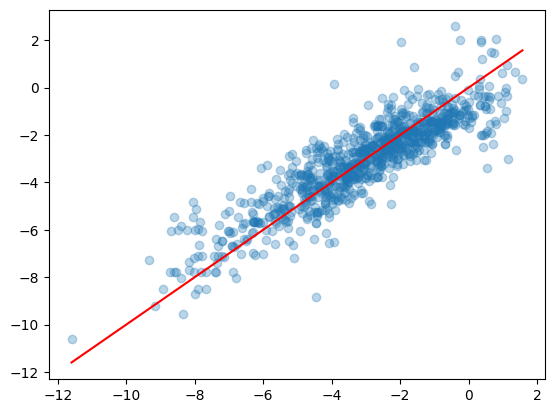

In [32]:
plt.scatter(Y_train,lr.predict(X_train),alpha=0.3)
plt.plot([Y_train.min(), Y_train.max()],
         [Y_train.min(), Y_train.max()],
         color='red')
plt.show()

As you can see in both scatter plots, the cloud of data points is distributed around the line, which indicates that the model's predictions are fairly accurate.

## **Apenddix: Random Forest**

In this final section, we use a Random Forest model to evaluate how well it performs on the same dataset and compare it with the Linear Regression model developed above.

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
rf=RandomForestRegressor(max_depth=2,random_state=11)
rf.fit(X_train,Y_train)

RandomForestRegressor(max_depth=2, random_state=11)

In [24]:
Y_rf_pred=rf.predict(X_test)
Y_rf_pred

array([-4.30061934, -1.43556358, -7.0225288 , -7.0225288 , -1.17107369,
       -1.4188296 , -1.17107369, -3.94999594, -2.26718118, -1.32895675,
       -4.33559087, -1.39171659, -4.40471016, -1.54311615, -1.32895675,
       -4.30061934, -2.94346132, -4.40471016, -1.25114177, -4.3679013 ,
       -1.17107369, -1.32671212, -2.56741463, -1.3852331 , -4.40471016,
       -2.65728748, -4.40471016, -1.67380789, -1.54311615, -1.27998904,
       -4.40471016, -4.30061934, -7.0225288 , -2.35705404, -1.32895675,
       -1.32895675, -1.4188296 , -1.4188296 , -1.17107369, -2.58213397,
       -4.40471016, -2.26718118, -1.3852331 , -4.05919424, -4.05919424,
       -1.54311615, -4.40471016, -2.56741463, -1.67380789, -4.30061934,
       -2.40953157, -1.32895675, -4.05919424, -2.40953157, -4.05919424,
       -2.26718118, -2.10929812, -2.40953157, -4.13941997, -3.14210207,
       -1.4188296 , -7.0225288 , -4.07671976, -1.63298901, -1.17107369,
       -2.36140231, -1.3852331 , -4.30061934, -5.12979845, -4.40

In [33]:
rf_mean_squared_error=mean_squared_error(Y_test,Y_rf_pred)
rf_r2_score=r2_score(Y_test,Y_rf_pred)
print("MSE:",rf_mean_squared_error)
print("RMSE:",sqrt(rf_mean_squared_error))
print("R2-score:",rf_r2_score)

MSE: 1.1679189261842793
RMSE: 1.080702977780796
R2-score: 0.7157798183304


According to these metrics, both models perform similarly, indicating that the Linear Regression captures most of the variability in the data and that using a more complex Random Forest model does not provide a significant improvement for this dataset.

Overall, this analysis demonstrates that for the Delaney dataset, a simple linear approach is nearly as effective as a more complex ensemble method, while still providing interpretable results.

I hope you enjoyed this simple project and gained some useful insights. Keep exploring and having fun with data on my GitHub profile!